Input shape:        torch.Size([1, 6, 64])
Output shape:       torch.Size([1, 6, 64])
Attention weights:  torch.Size([1, 4, 6, 6])


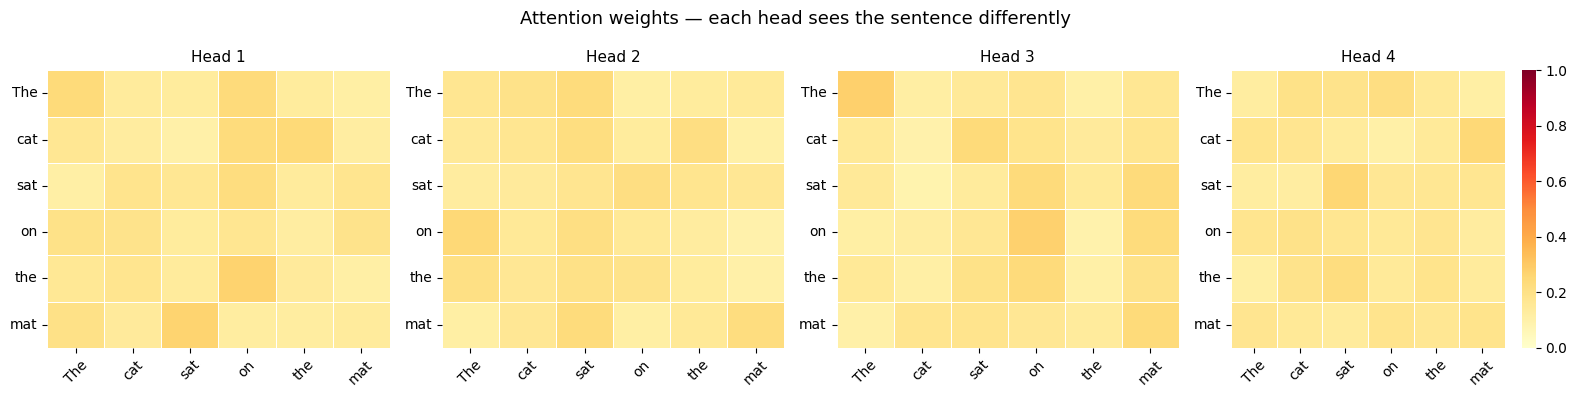


Total parameters in MHA: 16,640


In [1]:
# ============================================================
# Multi-Head Attention — from scratch in PyTorch
# Run this in Google Colab (no extra installs needed)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────
# 1. Single Scaled Dot-Product Attention
# ─────────────────────────────────────────
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (batch, heads, seq_len, d_k)
    K: (batch, heads, seq_len, d_k)
    V: (batch, heads, seq_len, d_v)
    Returns: output (same shape as V), attention weights
    """
    d_k = Q.size(-1)

    # Step 1: Compute raw scores — how much each query attends to each key
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    # scores shape: (batch, heads, seq_len, seq_len)

    # Step 2: Optional mask (for padding or causal/autoregressive models)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # Step 3: Softmax to get attention weights (probabilities)
    attn_weights = F.softmax(scores, dim=-1)

    # Step 4: Weighted sum of values
    output = torch.matmul(attn_weights, V)

    return output, attn_weights


# ─────────────────────────────────────────
# 2. Multi-Head Attention Module
# ─────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        """
        d_model:   total embedding dimension (e.g. 512)
        num_heads: how many parallel attention heads (e.g. 8)
        d_k = d_model // num_heads  per-head dimension
        """
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model    = d_model
        self.num_heads  = num_heads
        self.d_k        = d_model // num_heads  # per-head dimension

        # Learnable projection matrices for Q, K, V, and output
        self.W_q = nn.Linear(d_model, d_model)  # projects input → queries
        self.W_k = nn.Linear(d_model, d_model)  # projects input → keys
        self.W_v = nn.Linear(d_model, d_model)  # projects input → values
        self.W_o = nn.Linear(d_model, d_model)  # output projection

    def split_heads(self, x):
        """
        Reshape (batch, seq_len, d_model)
               → (batch, num_heads, seq_len, d_k)
        Each head gets its own slice of the embedding.
        """
        batch, seq_len, d_model = x.size()
        x = x.view(batch, seq_len, self.num_heads, self.d_k)
        return x.transpose(1, 2)  # (batch, heads, seq_len, d_k)

    def forward(self, query, key, value, mask=None):
        # Step 1: Linear projections
        Q = self.W_q(query)  # (batch, seq_len, d_model)
        K = self.W_k(key)
        V = self.W_v(value)

        # Step 2: Split into multiple heads
        Q = self.split_heads(Q)  # (batch, heads, seq_len, d_k)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # Step 3: Scaled dot-product attention for each head (in parallel)
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        # attn_output: (batch, heads, seq_len, d_k)
        # attn_weights: (batch, heads, seq_len, seq_len)

        # Step 4: Concatenate heads back
        batch, heads, seq_len, d_k = attn_output.size()
        attn_output = attn_output.transpose(1, 2)           # (batch, seq_len, heads, d_k)
        attn_output = attn_output.contiguous().view(batch, seq_len, self.d_model)
        # Now shape is (batch, seq_len, d_model) — same as input!

        # Step 5: Final output projection
        output = self.W_o(attn_output)

        return output, attn_weights


# ─────────────────────────────────────────
# 3. Run a Forward Pass
# ─────────────────────────────────────────
d_model   = 64   # embedding dimension
num_heads = 4    # attention heads
seq_len   = 6    # sentence: "The cat sat on the mat"
batch     = 1

mha = MultiHeadAttention(d_model=d_model, num_heads=num_heads)

# Simulate token embeddings (random here, but in practice these come from an Embedding layer)
x = torch.randn(batch, seq_len, d_model)

# Self-attention: Q = K = V = x (the input attends to itself)
output, attn_weights = mha(x, x, x)

print(f"Input shape:        {x.shape}")           # (1, 6, 64)
print(f"Output shape:       {output.shape}")       # (1, 6, 64)  ← same!
print(f"Attention weights:  {attn_weights.shape}") # (1, 4, 6, 6)


# ─────────────────────────────────────────
# 4. Visualize Attention Weights
# ─────────────────────────────────────────
tokens = ["The", "cat", "sat", "on", "the", "mat"]

fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))
fig.suptitle("Attention weights — each head sees the sentence differently", fontsize=13)

for h in range(num_heads):
    weights = attn_weights[0, h].detach().numpy()  # (seq_len, seq_len)
    ax = axes[h]
    sns.heatmap(
        weights,
        ax=ax,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="YlOrRd",
        vmin=0, vmax=1,
        linewidths=0.5,
        cbar=(h == num_heads - 1)
    )
    ax.set_title(f"Head {h+1}", fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────
# 5. Parameter Count
# ─────────────────────────────────────────
total_params = sum(p.numel() for p in mha.parameters())
print(f"\nTotal parameters in MHA: {total_params:,}")
# For d_model=512, num_heads=8 (like original Transformer): 4 × 512×512 = 1,048,576 params